# Customer Sentiment Dataset — Exploratory Data Analysis

This notebook explores a customer feedback dataset of **25,000 online orders**, covering customer demographics, purchase context, ratings, review text, sentiment labels, support response times, and complaint/resolution outcomes.

**Goals of this notebook:**
1. Understand the shape and quality of the data
2. Explore each column and its distribution
3. Uncover the relationships that actually drive `sentiment`, `complaint_registered`, and `issue_resolved`
4. Set up a clear foundation for the modeling notebook (`model_training.ipynb`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('../data/customer_sentiment.csv')
df.shape

(25000, 13)

In [2]:
df.head()

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


## 1. Data Quality Check

No missing values anywhere, and every row is a unique customer order. `purchase_channel` only ever takes the value `online`, so it carries no information and will be dropped going forward.

In [3]:
print(df.isnull().sum())
print()
print('Unique values per column:')
print(df.nunique())
print()
print("purchase_channel unique values:", df['purchase_channel'].unique())

customer_id             0
gender                  0
age_group               0
region                  0
product_category        0
purchase_channel        0
platform                0
customer_rating         0
review_text             0
sentiment               0
response_time_hours     0
issue_resolved          0
complaint_registered    0
dtype: int64

Unique values per column:
customer_id             25000
gender                      3
age_group                   5
region                      5
product_category            9
purchase_channel            1
platform                   20
customer_rating             5
review_text                15
sentiment                   3
response_time_hours        71
issue_resolved              2
complaint_registered        2
dtype: int64

purchase_channel unique values: <StringArray>
['online']
Length: 1, dtype: str


In [4]:
df = df.drop(columns=['purchase_channel'])

## 2. Who are the customers?

Quick look at the demographic and purchase-context columns.

/tmp/ipykernel_141/3224178699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette='viridis')
/tmp/ipykernel_141/3224178699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette='viridis')
/tmp/ipykernel_141/3224178699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette='viridis')
/tmp/ipykernel_141/3224178699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

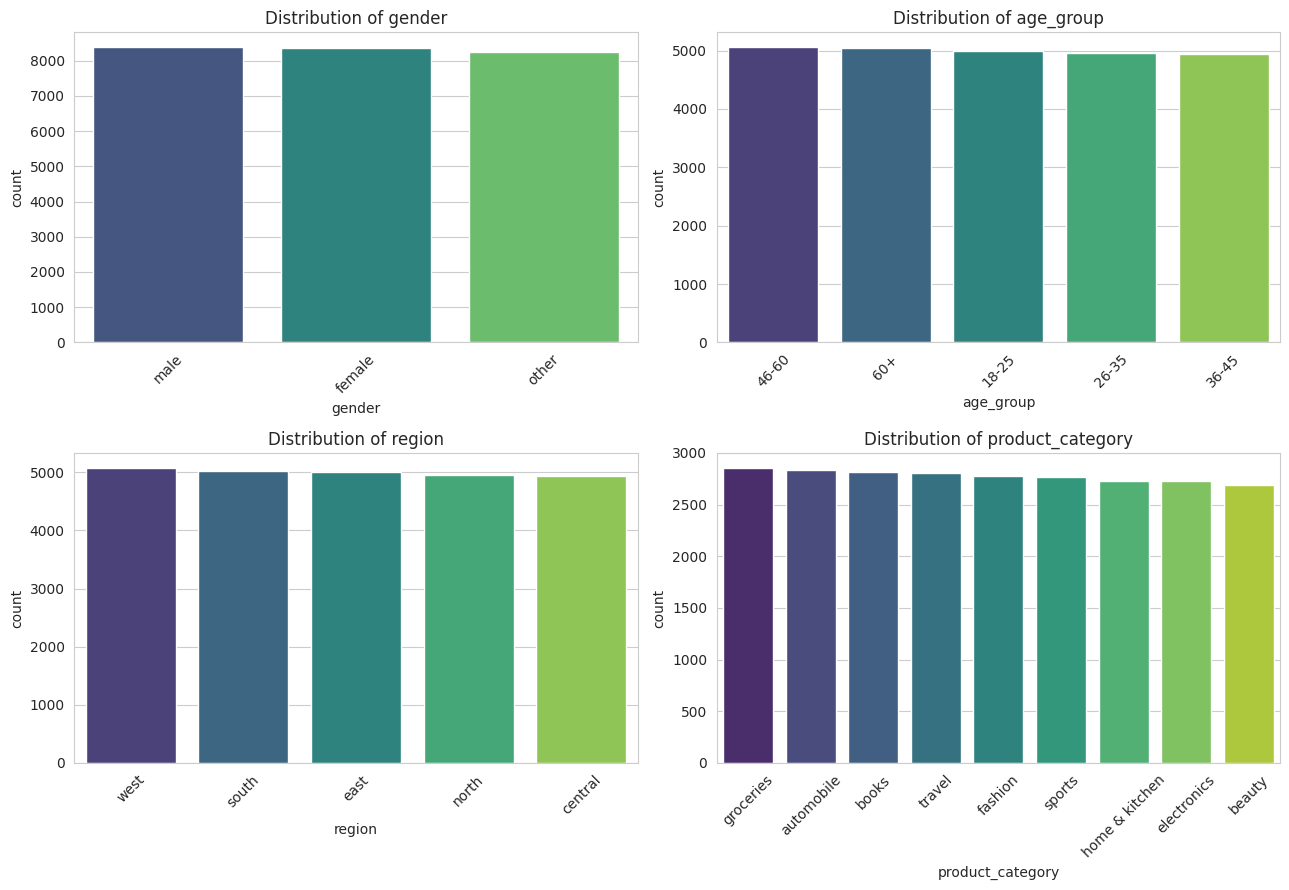

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, ['gender', 'age_group', 'region', 'product_category']):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette='viridis')
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../app/assets_demographics.png', dpi=100) if False else None
plt.show()

/tmp/ipykernel_141/3671592168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='platform', order=df['platform'].value_counts().index, palette='mako')


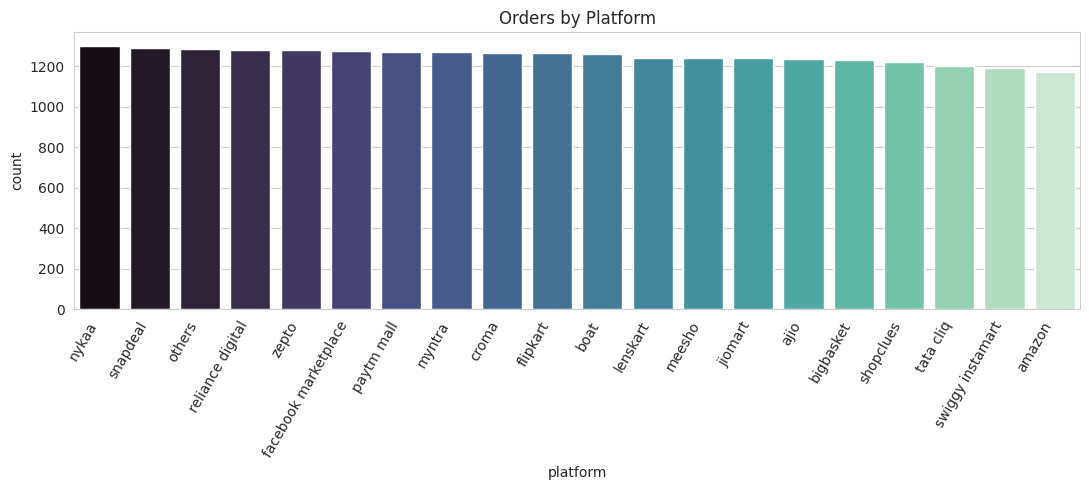

In [6]:
plt.figure(figsize=(11,5))
sns.countplot(data=df, x='platform', order=df['platform'].value_counts().index, palette='mako')
plt.title('Orders by Platform')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

Demographics and platform usage are close to evenly spread — this was designed as a balanced synthetic dataset, not skewed toward any one segment.

## 3. Ratings, sentiment and review text — how are they related?

This is the most important discovery in the whole dataset.

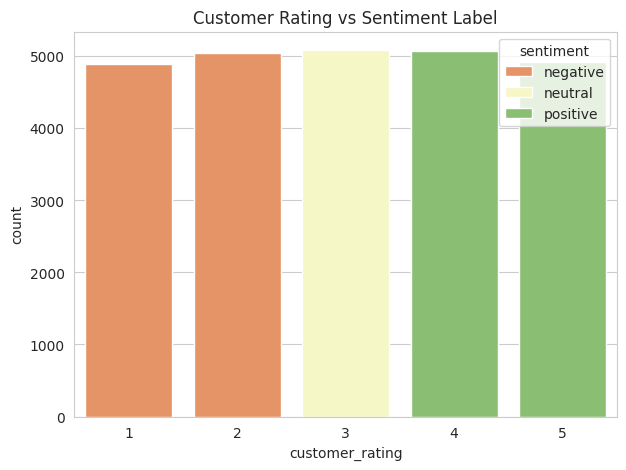

sentiment,negative,neutral,positive
customer_rating,,,
1,4891,0,0
2,5046,0,0
3,0,5085,0
4,0,0,5066
5,0,0,4912


In [7]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='customer_rating', hue='sentiment', palette='RdYlGn')
plt.title('Customer Rating vs Sentiment Label')
plt.show()

pd.crosstab(df['customer_rating'], df['sentiment'])

**Finding:** `sentiment` is a *perfect, deterministic function of `customer_rating`*:
- rating 1 or 2 → always `negative`
- rating 3 → always `neutral`
- rating 4 or 5 → always `positive`

There is zero overlap. This means sentiment isn't something that needs "predicting" once you already have the numeric rating — the two are the same information in two different forms.

In [8]:
df.groupby('sentiment')['review_text'].unique()

sentiment
negative    [very disappointed with the quality., product ...
neutral     [neutral about the quality., product is okay, ...
positive    [fast delivery and great packaging., amazing e...
Name: review_text, dtype: object

**Finding:** `review_text` is also templated — only **15 distinct review sentences** exist in the whole 25,000-row dataset, and each one maps to exactly one sentiment. So `review_text` is a *text-form encoding of the same rating/sentiment signal*, not independent, organic customer writing.

This matters a lot for modeling: if we predict sentiment using `customer_rating` or `review_text` as an input feature, the model will trivially hit 100% accuracy — it's memorizing a lookup table, not learning anything. We'll come back to this in the modeling notebook: sentiment will instead be predicted **from the review text alone, as an NLP task**, and separately we'll check whether customer demographics (gender, age, region, platform) carry *any* independent signal about sentiment.

In [9]:
demo_cols = ['gender', 'age_group', 'region', 'product_category', 'platform']
for col in demo_cols:
    print(col)
    print((df.groupby(col)['sentiment'].value_counts(normalize=True) * 100).round(1))
    print()

gender
gender  sentiment
female  positive     39.7
        negative     39.6
        neutral      20.7
male    positive     39.9
        negative     39.8
        neutral      20.3
other   positive     40.2
        negative     39.8
        neutral      20.1
Name: proportion, dtype: float64

age_group
age_group  sentiment
18-25      positive     40.4
           negative     39.5
           neutral      20.1
26-35      positive     40.5
           negative     40.2
           neutral      19.3
36-45      negative     39.8
           positive     39.1
           neutral      21.1
46-60      negative     40.1
           positive     39.6
           neutral      20.4
60+        positive     40.0
           negative     39.2
           neutral      20.8
Name: proportion, dtype: float64

region
region   sentiment
central  positive     40.7
         negative     38.4
         neutral      20.9
east     positive     40.1
         negative     40.1
         neutral      19.8
north    positive  

**Finding:** Across gender, age group, region, product category, and platform, the negative/neutral/positive split stays at roughly **40% / 20% / 40%** everywhere. Demographics carry essentially *no* independent information about sentiment in this dataset — sentiment is driven entirely by the rating a customer gave, not by who they are or what they bought.

## 4. What drives complaints?

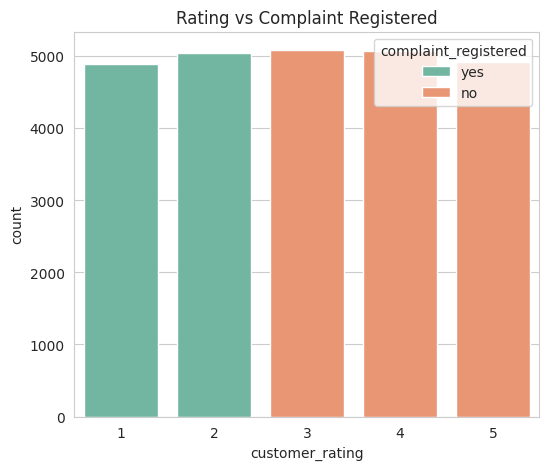

complaint_registered,no,yes
customer_rating,,
1,0,4891
2,0,5046
3,5085,0
4,5066,0
5,4912,0


In [10]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='customer_rating', hue='complaint_registered', palette='Set2')
plt.title('Rating vs Complaint Registered')
plt.show()

pd.crosstab(df['customer_rating'], df['complaint_registered'])

**Finding:** `complaint_registered` is also fully deterministic from rating: **every rating ≤ 2 has a complaint, every rating ≥ 3 does not** — a clean business rule, not a fuzzy tendency. Equivalently, `complaint_registered = (sentiment == 'negative')`.

## 5. What drives issue resolution?

This is the one relationship in the dataset that isn't just a restatement of the rating — and it's the most useful one for a real support operation.

/tmp/ipykernel_141/2742939593.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='issue_resolved', y='response_time_hours', palette='coolwarm')


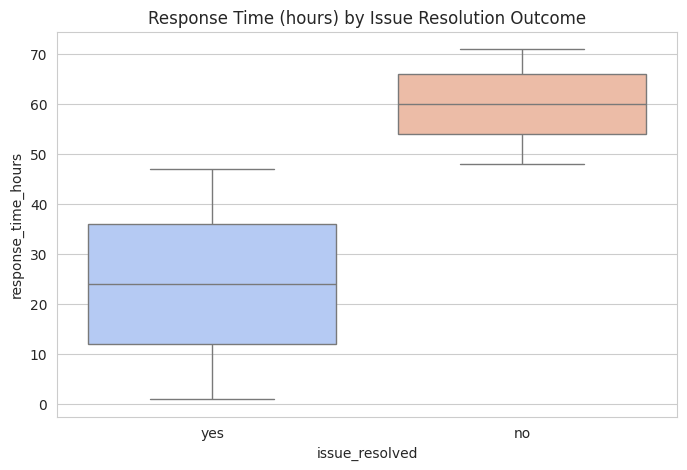

,count,mean,std,min,25%,50%,75%,max
issue_resolved,,,,,,,,
no,8407.0,59.695492,6.934420,48.0,54.0,60.0,66.0,71.0
yes,16593.0,24.029832,13.678527,1.0,12.0,24.0,36.0,47.0


In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='issue_resolved', y='response_time_hours', palette='coolwarm')
plt.title('Response Time (hours) by Issue Resolution Outcome')
plt.show()

df.groupby('issue_resolved')['response_time_hours'].describe()

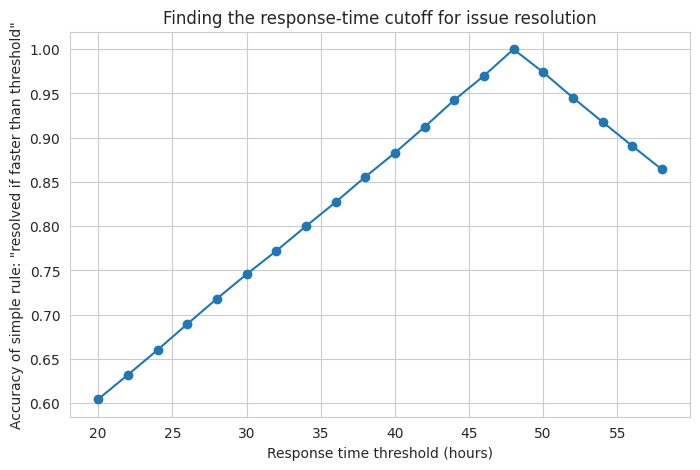

Best simple threshold ~ 48 hours, accuracy = 1.0000


In [12]:
thresholds = range(20, 60, 2)
accs = []
for t in thresholds:
    pred = np.where(df['response_time_hours'] < t, 'yes', 'no')
    accs.append((pred == df['issue_resolved']).mean())

plt.figure(figsize=(8,5))
plt.plot(list(thresholds), accs, marker='o')
plt.xlabel('Response time threshold (hours)')
plt.ylabel('Accuracy of simple rule: "resolved if faster than threshold"')
plt.title('Finding the response-time cutoff for issue resolution')
plt.show()

best_t = list(thresholds)[int(np.argmax(accs))]
print(f'Best simple threshold ~ {best_t} hours, accuracy = {max(accs):.4f}')

**Finding:** issues get resolved (`issue_resolved = yes`) whenever the support response time is **under ~48 hours**, and are marked unresolved whenever it's **48 hours or more** — a clean, near-perfect cutoff. Unlike rating → sentiment/complaint, this relationship is genuinely useful to model: response time is something a support team can actually *act on*, and this notebook shows that keeping response times under 2 days is the single biggest lever for resolving customer issues.

Rating, demographics, product category and platform show no meaningful relationship with `issue_resolved` — response time is the whole story.

In [13]:
for col in ['customer_rating'] + demo_cols + ['product_category']:
    pass

for col in ['customer_rating', 'gender', 'age_group', 'region', 'product_category', 'platform']:
    print(col)
    print((df.groupby(col)['issue_resolved'].value_counts(normalize=True) * 100).round(1))
    print()

customer_rating
customer_rating  issue_resolved
1                yes               66.5
                 no                33.5
2                yes               66.7
                 no                33.3
3                yes               66.5
                 no                33.5
4                yes               65.1
                 no                34.9
5                yes               67.0
                 no                33.0
Name: proportion, dtype: float64

gender
gender  issue_resolved
female  yes               66.7
        no                33.3
male    yes               66.8
        no                33.2
other   yes               65.6
        no                34.4
Name: proportion, dtype: float64

age_group
age_group  issue_resolved
18-25      yes               65.7
           no                34.3
26-35      yes               66.0
           no                34.0
36-45      yes               67.4
           no                32.6
46-60      yes              

## 6. Response time patterns

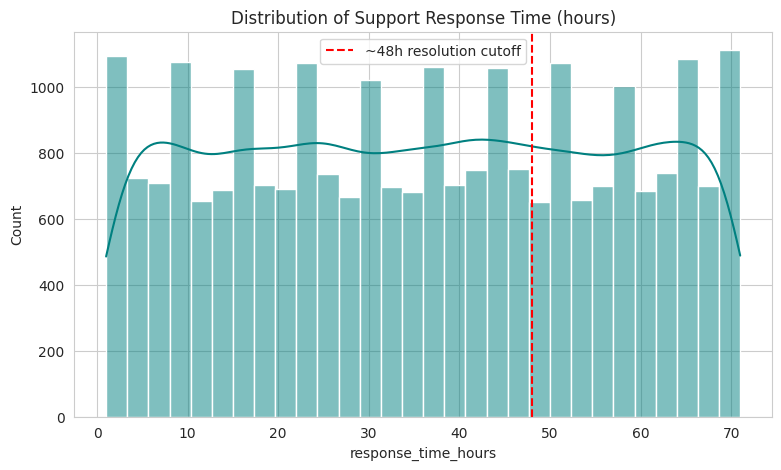

In [14]:
plt.figure(figsize=(9,5))
sns.histplot(df['response_time_hours'], bins=30, kde=True, color='teal')
plt.title('Distribution of Support Response Time (hours)')
plt.axvline(48, color='red', linestyle='--', label='~48h resolution cutoff')
plt.legend()
plt.show()

## 7. Summary of key findings

| Target | Real driver | Notes |
|---|---|---|
| `sentiment` | `customer_rating` (perfect 1:1 mapping) and `review_text` (templated, 15 fixed phrases) | Demographics carry no independent signal |
| `complaint_registered` | `customer_rating` (rating ≤ 2 ⇒ complaint, always) | Same information as sentiment, restated |
| `issue_resolved` | `response_time_hours` (< ~48h ⇒ resolved, always) | The one target with a genuinely actionable driver |

**Implications for modeling (`model_training.ipynb`):**
- **Sentiment** will be modeled as a text-classification problem — predicting sentiment from `review_text` alone (TF-IDF + classifiers), since that's the only way to make it a non-trivial NLP exercise.
- **Complaint registered** and **issue resolved** will be modeled as tabular classification problems using `customer_rating`, `response_time_hours`, and the demographic/purchase context columns, comparing several standard algorithms.
- Expect near-perfect scores on `complaint_registered` (rating alone gives it away) and strong-but-not-trivial scores on `issue_resolved`, since response time is a continuous variable a model has to learn a threshold for.


In [15]:
df.to_csv('../data/customer_sentiment_clean.csv', index=False)
print('Saved cleaned dataset for modeling.')

Saved cleaned dataset for modeling.
